In [27]:
# pip install tifffile dask[complete] imagecodecs zarr
import tifffile as tiff
import dask.array as da

path = '/Volumes/rkc_ramirezlab/Home/suthardr/Projects/2photon_menace/Astro2P_Pilot#3_2025July/Day 2 - FC/621N/20250708_FC_dualcolorpilot_fullsession_621N/0_13.ome.tiff'

with tiff.TiffFile(path) as tf:
    series = tf.series[0]
    print("axes:", series.axes)   # e.g. 'TCYX' or 'TZCYX'
    print("shape:", series.shape) # e.g. (27600, 608, 608) or (T,Z,C,Y,X)

    # Create a Zarr store from the TIFF and wrap it as a Dask array
    z = series.aszarr()                 # lazy, no data loaded yet
    darr = da.from_zarr(z)              # dask array, lazily reads tiles/pages

# Example: normalize to a standard axis order (T,Z,C,Y,X) with size 1 for missing dims
# Infer axes mapping
axes = series.axes
sizes = dict(zip(axes, darr.shape))
for ax in "TZCYX":
    sizes.setdefault(ax, 1)

# Move axes into T,Z,C,Y,X order
order = [axes.index(ax) if ax in axes else None for ax in "TZCYX"]
# Expand missing axes (dask supports reshape with singleton)
d = darr
for ax, idx in zip("TZCYX", order):
    if idx is None:
        d = d.reshape(d.shape + (1,))  # add singleton at end temporarily
        axes += ax                      # track we added it

# Recompute move order now that all axes exist
order = [axes.index(ax) for ax in "TZCYX"]
d = da.moveaxis(d, order, range(5))    # d has shape (T,Z,C,Y,X)

T,Z,C,Y,X = d.shape
print("standardized shape (T,Z,C,Y,X):", (T,Z,C,Y,X))

# Access a single channel lazily (e.g., green = channel 0, red = channel 1)
green = d[:, :, 0, :, :] if C > 1 else d[:, :, 0:1, :, :]
red   = d[:, :, 1, :, :] if C > 1 else None




axes: CTYX
shape: (2, 26229, 608, 608)
standardized shape (T,Z,C,Y,X): (26229, 1, 2, 608, 608)


In [ ]:

# green, red are already (T, Z, Y, X) from your code above:
green_ = green.rechunk((1, 1, -1, -1))
red_   = red.rechunk((1, 1, -1, -1))

# Write as OME-TIFF; tifffile will stream from Dask
tiff.imwrite(
    "/Users/suthardr/Desktop/channel-green.ome.tiff",
    green_, ome=True, bigtiff=True, compression="zlib",
    metadata={"axes": "TZYX"}, photometric="minisblack"
)
tiff.imwrite(
    "/Users/suthardr/Desktop/channel-red.ome.tiff",
    red_, ome=True, bigtiff=True, compression="zlib",
    metadata={"axes": "TZYX"}, photometric="minisblack"
)

In [ ]:
series.axes, series.shape, green.shape, green.chunks, red.shape, red.chunks

In [20]:
# pip install tifffile imagecodecs tqdm
from pathlib import Path
import numpy as np
import tifffile as tiff
from tqdm import tqdm

def save_channel_TZYX_as_ome(
    channel_tzyx, out_path,
    *, compression="zlib", bigtiff=True, time_step=1, z_mode="stack"
):
    """
    channel_tzyx: Dask array with shape (T,Z,Y,X)
    z_mode: 'stack' keeps Z; 'max' writes Z-projection but keeps Z=1 for consistent axes.
    """
    if channel_tzyx.ndim != 4:
        raise ValueError(f"Expected (T,Z,Y,X); got {channel_tzyx.shape}")

    out_path = Path(out_path)
    if out_path.exists():
        out_path.unlink()

    T, Z, Y, X = channel_tzyx.shape
    axes_tag = "TZYX"           # always declare TZYX
    t_indices = range(0, T, time_step) if T > 1 else [0]

    wrote_first = False
    for t in tqdm(t_indices, desc=f"Writing {out_path.name}"):
        vol = channel_tzyx[t].compute()          # (Z,Y,X), NumPy
        if z_mode == "max" and Z > 1:
            zyx = vol.max(axis=0, keepdims=True) # -> (1,Y,X)
        else:
            zyx = vol if vol.ndim == 3 else vol[None, ...]

        if not wrote_first:
            tiff.imwrite(
                out_path, np.asarray(zyx),
                bigtiff=bigtiff, compression=compression,
                photometric="minisblack", metadata={"axes": axes_tag}, ome=True
            )
            wrote_first = True
        else:
            tiff.imwrite(
                out_path, np.asarray(zyx),
                append=True, compression=compression, photometric="minisblack"
            )
    return str(out_path)

# ---- Use with your arrays ----
# If your file has no Z dimension:
green = d[:, 0, 0, :, :]  # (T,Y,X)  -> expand to T,Z=1,Y,X:
green = green[:, None, :, :]
red   = d[:, 0, 1, :, :]
red   = red[:, None, :, :]


g_path = save_channel_TZYX_as_ome(
    green, "/Users/suthardr/Desktop/channel-green.ome.tiff",
    compression="zlib", bigtiff=True, time_step=1, z_mode="stack"   # or "max"
)
r_path = save_channel_TZYX_as_ome(
    red, "/Users/suthardr/Desktop/channel-red.ome.tiff",
    compression="zlib", bigtiff=True, time_step=1, z_mode="stack"
)
print("Saved:", g_path, r_path)


Writing channel-green.ome.tiff:   0%|          | 0/26229 [00:00<?, ?it/s]


ValueError: axes do not match shape

In [112]:
result = LTP_mean_traceA - LTP_mean_traceN
result = result[0:8000]

Text(0, 0.5, 'Average Pixel Intensity (Baseline Shifted)')

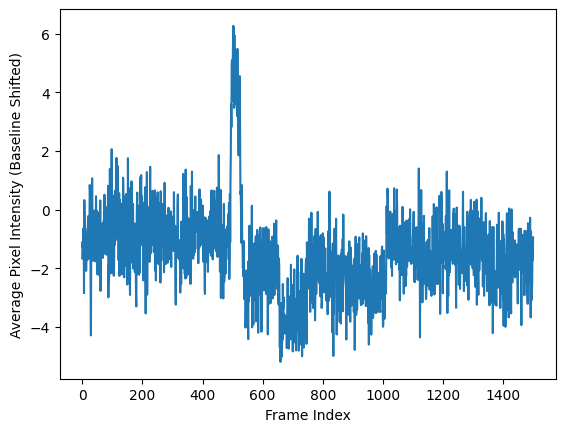

In [116]:
plt.plot(result[1000:2500])
plt.xlabel("Frame Index")
plt.ylabel("Average Pixel Intensity (Baseline Shifted)")